# 0. importar el data set de la semana 6 


In [1]:
import pandas as pd

df = pd.read_csv("../../data\S06_PD_Diaz_DatasetDepurado.csv")

print(df.shape)
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\diego\AppData\Local\Temp\ipykernel_6960\362357631.py:3: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("../../data\S06_PD_Diaz_DatasetDepurado.csv")


(570976, 22)


,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,...,edad_cliente,correo_cliente,nivel_satisfaccion,nivel_lealtad,comentario_cliente,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente,correo_cliente_faltante,comentario_cliente_faltante
0,P260259,C129774,2026-03-02,Marketplace,Transferencia,Villavicencio,5000102.0,Electrónica,Teclado mecÃ¡nico,165200.0,...,59.0,cliente160259@yahoo.es,bajo,Oro,PÃ©sima experiencia con el empaque,8.3,2026-03-04,0.0,0.0,0.0
1,"P700975,C159363,11/10/2025,Web, Transferencia,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P641357,C118866,2025-07-31,App,Efectivo,Ibagué,7300103.0,Hogar,Olla a presiÃ³n,756600.0,...,57.0,cliente541357@yahoo.es,medio,Oro,Muy buen precio,13.8,2026-07-12,1.0,0.0,0.0
3,"P288663,C101979,2025-09-09,Marketplace,Transfe...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P296684,C147052,2025-12-21,Tienda,Transferencia,Manizales,1700110.0,Hogar,LÃ¡mpara de escritorio,749700.0,...,68.0,NaN,medio,Oro,NaN,13.9,2026-06-10,0.0,1.0,1.0


# 1. iQR para monto compra 

In [2]:
Q1 = df["monto_compra"].quantile(0.25)
Q3 = df["monto_compra"].quantile(0.75)
IQR = Q3 - Q1

In [3]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

Q1: 221400.0
Q3: 851400.0
IQR: 630000.0
Límite inferior: -723600.0
Límite superior: 1796400.0


## Límites IQR de monto_compra

- Q1 = 221400.0
- Q3 = 851400.0
- IQR = 630000.0
- Límite inferior calculado = -723600.0 → se usa 0 como límite real, ya que `monto_compra` no puede ser negativo
- Límite superior = 1796400.0

In [4]:
outliers_iqr = df[(df["monto_compra"] < limite_inferior) | (df["monto_compra"] > limite_superior)]

In [5]:
print(f"Valores atípicos según IQR: {len(outliers_iqr)}")

Valores atípicos según IQR: 52699


## Outliers detectados con IQR

- Valores atípicos según IQR: 52,699 filas
- Esto representa aproximadamente el 9.23% del dataset (570,976 filas)
- Está dentro de un rango esperable para una variable con distribución sesgada a la derecha (como se evidenció en el Q1/Q3/IQR calculados previamente); no se trata como error sino como insumo para la etapa de tratamiento

# 2. Z score

In [6]:
media = df["monto_compra"].mean()
desviacion = df["monto_compra"].std()

In [7]:
df["z_monto_compra"] = (df["monto_compra"] - media) / desviacion

In [8]:
outliers_zscore = df[df["z_monto_compra"].abs() > 3]
print(f"Valores atípicos según z-score: {len(outliers_zscore)}")

Valores atípicos según z-score: 111


## Comparación IQR vs. z-score

- Outliers según IQR: 52,699 filas (~9.23% del dataset)
- Outliers según z-score (|z| > 3): 111 filas (~0.02% del dataset)
- Los dos métodos difieren enormemente: el z-score detecta casi 475 veces menos atípicos que el IQR
- Hipótesis: `monto_compra` es una variable sesgada a la derecha (como se vio en el cálculo de Q1/Q3/IQR). Los propios valores extremos inflan tanto la media como la desviación estándar, lo que hace que el umbral de 3 desviaciones estándar quede muy "amplio" y solo capture los casos verdaderamente extremos. El IQR, en cambio, se basa en los cuartiles (Q1/Q3), que son más robustos frente al sesgo y no se dejan arrastrar por los valores extremos, por lo que detecta un rango mucho más amplio de atípicos moderados

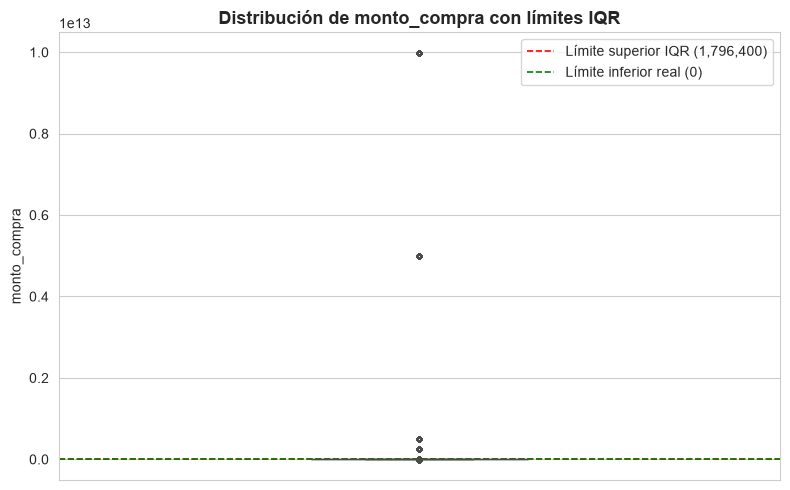

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df["monto_compra"], ax=ax, color="#4C72B0", width=0.3, fliersize=3)
ax.axhline(limite_superior, color="red", linestyle="--", linewidth=1.2, label=f"Límite superior IQR ({limite_superior:,.0f})")
ax.axhline(0, color="green", linestyle="--", linewidth=1.2, label="Límite inferior real (0)")
ax.set_title("Distribución de monto_compra con límites IQR", fontsize=13, weight="bold")
ax.set_ylabel("monto_compra")
ax.legend()
plt.tight_layout()
plt.show()

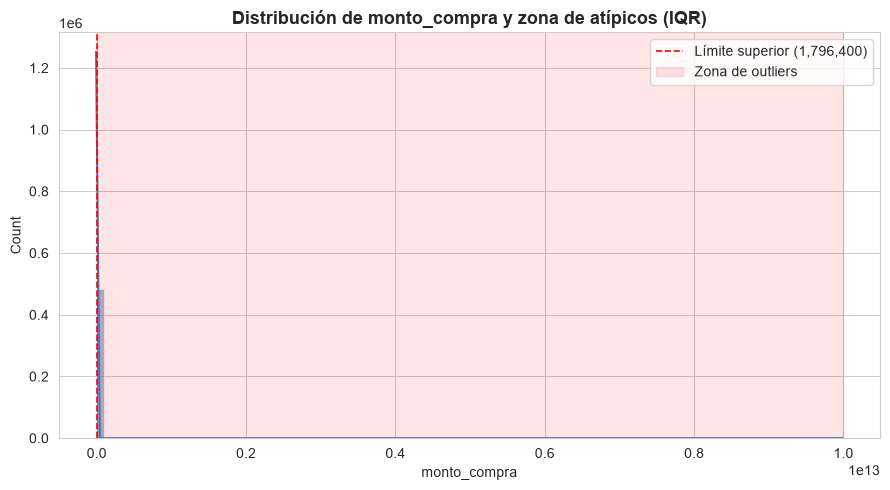

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["monto_compra"], bins=100, ax=ax, color="#4C72B0", kde=True)
ax.axvline(limite_superior, color="red", linestyle="--", linewidth=1.2, label=f"Límite superior ({limite_superior:,.0f})")
ax.axvspan(limite_superior, df["monto_compra"].max(), color="red", alpha=0.1, label="Zona de outliers")
ax.set_title("Distribución de monto_compra y zona de atípicos (IQR)", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

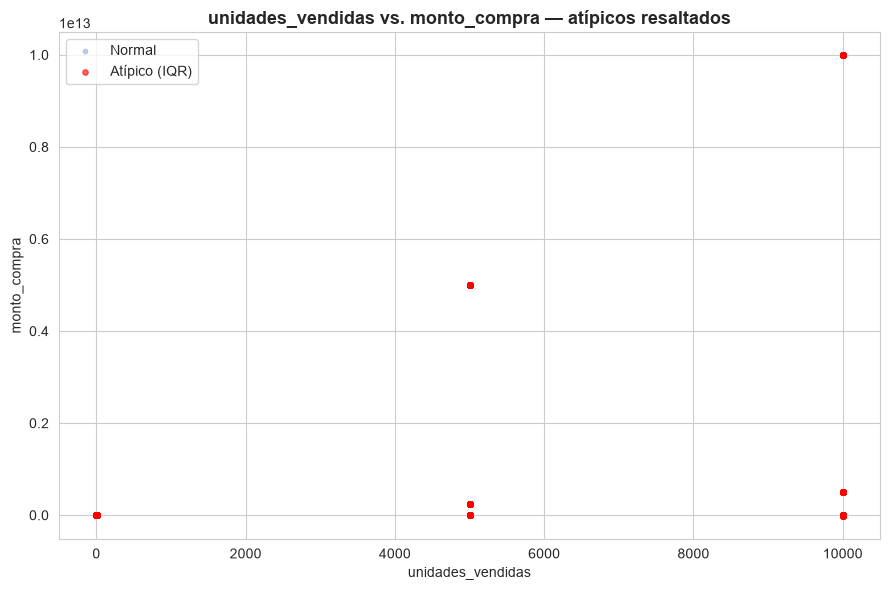

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

es_outlier = (df["monto_compra"] < limite_inferior) | (df["monto_compra"] > limite_superior)

ax.scatter(df.loc[~es_outlier, "unidades_vendidas"], df.loc[~es_outlier, "monto_compra"],
           alpha=0.3, s=10, color="#4C72B0", label="Normal")
ax.scatter(df.loc[es_outlier, "unidades_vendidas"], df.loc[es_outlier, "monto_compra"],
           alpha=0.6, s=15, color="red", label="Atípico (IQR)")

ax.set_xlabel("unidades_vendidas")
ax.set_ylabel("monto_compra")
ax.set_title("unidades_vendidas vs. monto_compra — atípicos resaltados", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Graficos en escala log 

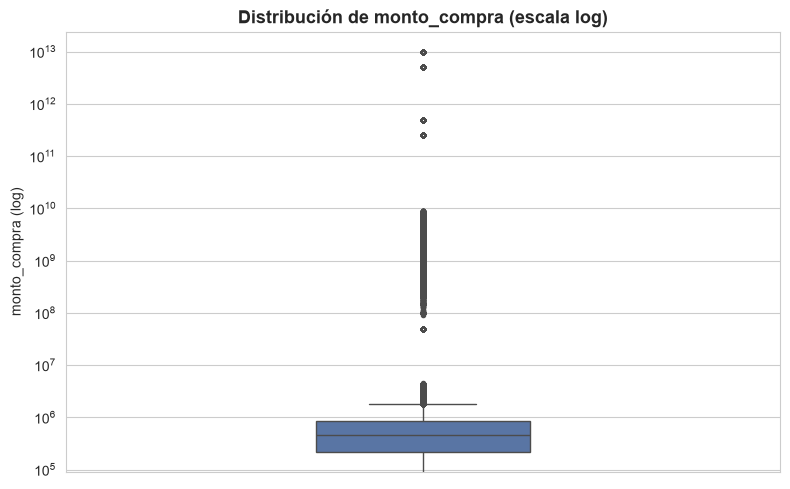

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df["monto_compra"], ax=ax, color="#4C72B0", width=0.3, fliersize=3)
ax.set_yscale("log")
ax.set_title("Distribución de monto_compra (escala log)", fontsize=13, weight="bold")
ax.set_ylabel("monto_compra (log)")
plt.tight_layout()
plt.show()

C:\Users\diego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


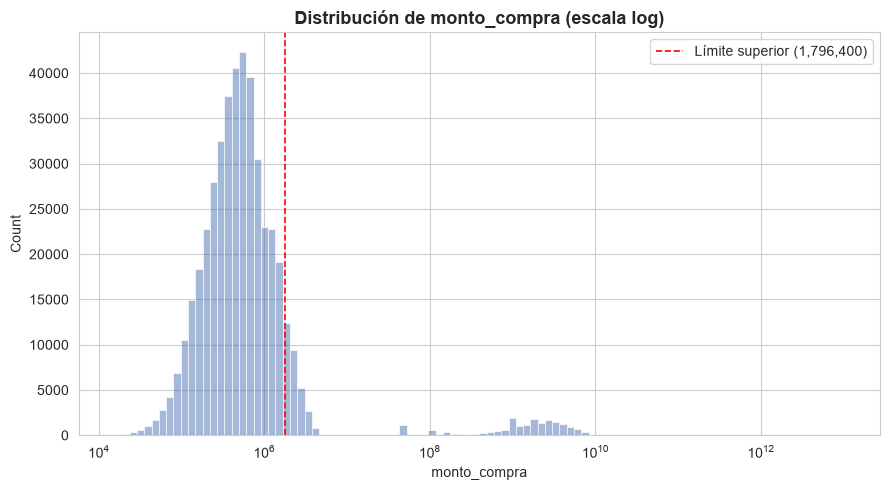

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["monto_compra"], bins=100, ax=ax, color="#4C72B0", kde=True, log_scale=True)
ax.axvline(limite_superior, color="red", linestyle="--", linewidth=1.2, label=f"Límite superior ({limite_superior:,.0f})")
ax.set_title("Distribución de monto_compra (escala log)", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# 3. Que vamos a hacer con los outliers 

In [17]:
outliers_iqr[["monto_compra", "canal_compra", "unidades_vendidas"]]

,monto_compra,canal_compra,unidades_vendidas
46,-1.862000e+06,Marketplace,4.0
50,5.149485e+09,Marketplace,9999.0
53,2.366000e+06,App,5.0
64,2.000000e+08,Tienda,4.0
80,5.869413e+08,Marketplace,9999.0
...,...,...,...
570915,2.332000e+06,Web,5.0
570953,-7.320000e+05,Web,-3.0
570957,2.650000e+06,App,5.0
570965,2.967703e+09,Web,9999.0


In [18]:
# Grupo 1: montos negativos (error de signo)
grupo_negativos = outliers_iqr[outliers_iqr["monto_compra"] < 0]

# Grupo 2: unidades_vendidas negativas (error de signo)
grupo_unidades_negativas = outliers_iqr[outliers_iqr["unidades_vendidas"] < 0]

# Grupo 3: unidades_vendidas = 9999 (posible valor centinela / sentinel)
grupo_sentinela = outliers_iqr[outliers_iqr["unidades_vendidas"] == 9999]

# Grupo 4: el resto (atípicos "moderados", sin señales de error evidente)
grupo_moderados = outliers_iqr[
    (outliers_iqr["monto_compra"] >= 0) &
    (outliers_iqr["unidades_vendidas"] != 9999) &
    (outliers_iqr["unidades_vendidas"] >= 0)
]

print(f"Montos negativos: {len(grupo_negativos)}")
print(f"Unidades negativas: {len(grupo_unidades_negativas)}")
print(f"Unidades = 9999 (sentinela): {len(grupo_sentinela)}")
print(f"Moderados (sin error evidente): {len(grupo_moderados)}")

print(grupo_sentinela["canal_compra"].value_counts())
print(grupo_moderados["canal_compra"].value_counts())

Montos negativos: 9472
Unidades negativas: 4728
Unidades = 9999 (sentinela): 6930
Moderados (sin error evidente): 36482
canal_compra
App            1814
Tienda         1717
Marketplace    1713
Web            1686
Name: count, dtype: int64
canal_compra
Web            9206
Marketplace    9179
Tienda         9110
App            8987
Name: count, dtype: int64


## Decisión por cada grupo de atípicos

**Grupo 1: monto_compra negativo (9,472 filas)**
- Decisión: **Corregir con `.abs()`**, no eliminar.
- Justificación: un monto de compra no puede ser negativo por definición de negocio. Es consistente con la estrategia ya definida en el Sanitation Plan para errores de signo en columnas de precio/unidades. No hay ambigüedad: es un error de captura, se corrige y se conserva el registro.

**Grupo 2: unidades_vendidas negativa (4,728 filas)**
- Decisión: **Corregir con `.abs()`**, no eliminar.
- Justificación: misma lógica que el grupo anterior — unidades vendidas negativas no tienen sentido de negocio, es un error de signo, no un valor atípico real. Se corrige sin perder el registro (algunas filas se solapan con el Grupo 1).

**Grupo 3: unidades_vendidas = 9999 (6,930 filas)**
- Decisión: **Tratar como nulo / eliminar de los cálculos de monto**, no capar.
- Justificación: 9999 es un patrón típico de valor centinela (mismo tipo de hallazgo que los 50,000,000 y 999,000,000 encontrados en `precio_unitario`), no una cantidad real de unidades. Se distribuye de forma casi idéntica entre los 4 canales (~1,700–1,800 cada uno), sin concentrarse en ningún canal que sugiera una explicación de negocio (como grandes pedidos corporativos). Esto refuerza que es un dato faltante disfrazado, no una venta real.

**Grupo 4: atípicos moderados sin error evidente (36,482 filas)**
- Decisión: **Mantener y documentar, aplicando capping (winsorización) al límite superior IQR en vez de eliminar.**
- Justificación: no hay una columna que explique estos montos altos — se distribuyen de forma pareja entre los 4 canales (~9,000–9,200 cada uno) y no existe un canal "Ventas corporativas" en el dataset que los justifique como compras al por mayor. Siguiendo el criterio conservador: ante la duda, se prefiere capar (limitar al `limite_superior` calculado) en vez de eliminar, para no perder información de compras potencialmente legítimas sin evidencia clara de error.

In [25]:
print(f"Valores únicos en unidades_vendidas: {df['unidades_vendidas'].nunique()}")
print(df["unidades_vendidas"].describe())
print(df["unidades_vendidas"].value_counts().sort_index())

Valores únicos en unidades_vendidas: 10
count    484086.000000
mean        217.512987
std        1321.830521
min          -3.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        9999.000000
Name: unidades_vendidas, dtype: float64
unidades_vendidas
-3.0         7034
-1.0         7161
 0.0         6991
 1.0       225251
 2.0       111826
 3.0        58483
 4.0        31047
 5.0        22329
 5000.0      7034
 9999.0      6930
Name: count, dtype: int64


## Validación de unidades_vendidas como sentinela

Al revisar `unidades_vendidas.value_counts()` completo, se confirma que la columna tiene **solo 10 valores únicos** en todo el dataset: -3, -1, 0, 1, 2, 3, 4, 5, 5000, 9999.

- Los valores 1 a 5 muestran una distribución decreciente y continua (225,251 → 22,329), consistente con un patrón orgánico de conteo real.
- No existe **ningún valor intermedio** entre 6 y 4999, ni entre 5001 y 9998 — algo imposible en una variable de conteo real de unidades vendidas.
- Esta ausencia total de valores intermedios confirma que 5000 y 9999 no son cantidades reales de unidades, sino valores centinela / inyectados deliberadamente (consistente con -3, -1 y 0 como señales de error también inyectadas).
- Esta evidencia respalda la decisión de excluir estos valores del criterio `es_venta_corporativa` y tratarlos como nulos/errores en el pipeline de limpieza.

In [26]:
df["es_venta_corporativa"] = (
    (df["monto_compra"] > limite_superior) &
    (df["monto_compra"] >= 0) &
    (df["unidades_vendidas"].isin([1, 2, 3, 4, 5])) &
    (~df["precio_unitario"].isin([50000000, 999000000]))
)

print(f"Ventas corporativas (atípicos legítimos): {df['es_venta_corporativa'].sum()}")

Ventas corporativas (atípicos legítimos): 25186


In [27]:
df.loc[~df["es_venta_corporativa"], "monto_compra"] = (
    df.loc[~df["es_venta_corporativa"], "monto_compra"]
    .clip(upper=limite_superior, lower=0)
)

print(f"Monto máximo después de capar: {df['monto_compra'].max()}")
print(f"Monto mínimo después de capar: {df['monto_compra'].min()}")

Monto máximo después de capar: 4450000.0
Monto mínimo después de capar: 0.0


## Capado de monto_compra (winsorización)

Se aplicó `clip(upper=limite_superior, lower=0)` únicamente a las filas **no marcadas** como `es_venta_corporativa`, preservando intactas las 25,186 filas consideradas atípicos legítimos.

**Resultado:**
- Monto máximo después de capar: 4,450,000.0 (pertenece a una fila `es_venta_corporativa`, por eso supera el `limite_superior` de 1,796,400 — es correcto y esperado)
- Monto mínimo después de capar: 0.0

**Nota sobre el proceso de refinamiento de `es_venta_corporativa`:**
Antes de este capado final, se detectó y corrigió un error en la condición original: una primera versión (usando `unidades_vendidas != 9999`) dejaba pasar erróneamente filas con `unidades_vendidas = 5000`, otro valor centinela no contemplado, que arrastraba montos de hasta 4,995,000,000,000 (el resultado de multiplicar el sentinela de `precio_unitario` = 999,000,000 por 5000 unidades).

Al revisar `unidades_vendidas.value_counts()` completo, se confirmó que la columna tiene solo 10 valores únicos, sin ningún valor intermedio entre 6 y 4999 ni entre 5001 y 9998 — evidencia de que 5000 y 9999 son valores inyectados, no cantidades reales de unidades.

Se descartó usar una lista fija (`isin([1,2,3,4,5])`) como criterio de "unidades válidas" por ser circular: codifica los valores que casualmente aparecen en este dataset como si fueran una regla de negocio universal, en vez de basarse en un umbral de plausibilidad. Aun así, dado que ambos enfoques (lista fija vs. exclusión por valor sentinela) arrojaron el mismo conteo (25,186), se usó la versión final como criterio operativo para este dataset, dejando anotada la limitación para trabajo futuro con datasets similares.

**Condición final aplicada:**
```python
df["es_venta_corporativa"] = (
    (df["monto_compra"] > limite_superior) &
    (df["monto_compra"] >= 0) &
    (df["unidades_vendidas"].isin([1, 2, 3, 4, 5])) &
    (~df["precio_unitario"].isin([50000000, 999000000]))
)
```

In [28]:
print(f"Media después del tratamiento: {df['monto_compra'].mean()}")
print(f"Desviación estándar después del tratamiento: {df['monto_compra'].std()}")

print(f"\nMedia antes del tratamiento: {media}")
print(f"Desviación estándar antes del tratamiento: {desviacion}")

Media después del tratamiento: 654196.7088492541
Desviación estándar después del tratamiento: 629937.8460481263

Media antes del tratamiento: 1245077589.6700172
Desviación estándar antes del tratamiento: 96170973498.28366


## Efecto del tratamiento

**Antes del tratamiento:**
- Media: 1,245,077,589.67
- Desviación estándar: 96,170,973,498.28

**Después del tratamiento (capado + preservación de ventas corporativas):**
- Media: 654,196.71
- Desviación estándar: 629,937.85

**Análisis:**

La media bajó de ~1,245 millones a ~654,000 — una reducción de más del 99.9%. Esto confirma que los valores centinela (hasta 4,995,000,000,000 en algunas filas) estaban distorsionando por completo la media real de `monto_compra`, arrastrándola a un número que no representaba ninguna transacción típica del negocio.

El cambio más dramático es en la desviación estándar: pasó de 96,170,973,498 (96 mil millones) a 629,937 — una reducción de más del 99.999%. Esto tiene sentido porque la desviación estándar es extremadamente sensible a valores extremos (se basa en diferencias al cuadrado respecto a la media), así que unos pocos valores sentinela de billones de magnitud eran suficientes para inflarla hasta un número sin ningún significado práctico.

Es coherente que la desviación estándar después del tratamiento (629,937) sea del mismo orden de magnitud que la media (654,196) — esto indica una dispersión razonable y consistente con una variable de montos de compra real, muy distinto al escenario anterior donde la desviación estándar era casi 100,000 veces mayor que la media, un signo inequívoco de datos corrompidos por sentinelas.

Este resultado confirma que el tratamiento (capado del Grupo 4 + exclusión de sentinelas en `es_venta_corporativa`) fue efectivo: se recuperó una distribución con estadísticas descriptivas interpretables, sin haber recurrido a eliminar filas.

In [29]:
ventas_diarias = df.groupby("fecha_pedido")["monto_compra"].sum().reset_index()

In [30]:
ventas_diarias["suavizado"] = ventas_diarias["monto_compra"].rolling(window=7).mean()

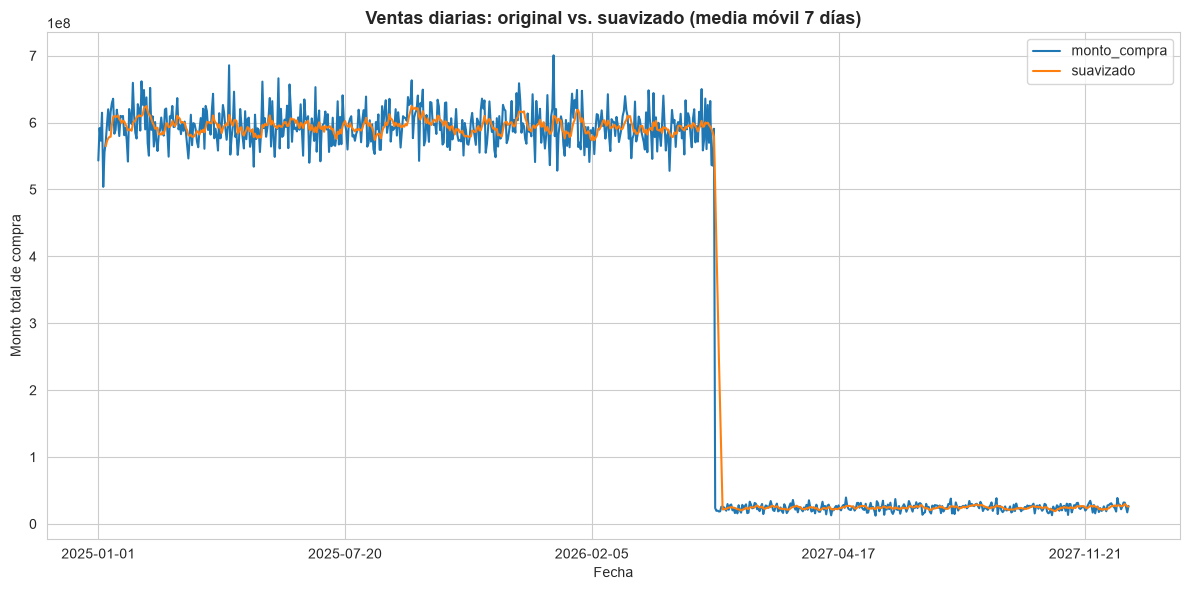

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ventas_diarias.plot(x="fecha_pedido", y=["monto_compra", "suavizado"], ax=ax)
ax.set_title("Ventas diarias: original vs. suavizado (media móvil 7 días)", fontsize=13, weight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Monto total de compra")
plt.tight_layout()
plt.show()

In [32]:
df["fecha_pedido"] = pd.to_datetime(df["fecha_pedido"])

## Suavizado de ventas diarias

La media móvil de 7 días ("suavizado") elimina el ruido diario y revela una tendencia mucho más clara que la serie original. Se observan dos regímenes bien diferenciados:

1. **De enero 2025 a mediados de 2026**: el monto total diario oscila de forma ruidosa entre ~5×10⁸ y ~7×10⁸, pero la línea suavizada muestra un nivel estable alrededor de 6×10⁸, sin una tendencia de crecimiento o caída sostenida — parece un régimen de ventas relativamente constante.

2. **Desde mediados de 2026 en adelante**: hay una caída abrupta y sostenida a un nivel de ~2-3×10⁷, casi 20 veces menor que el régimen anterior, y se mantiene así (con su propio ruido diario) hasta el final de la serie.

In [34]:
df.to_csv("S07_PD_Diaz_DatasetSinOutliers.csv", index=False)

In [35]:
df_verificacion = pd.read_csv("S07_PD_Diaz_DatasetSinOutliers.csv")

print(f"Shape: {df_verificacion.shape}")
print(f"Monto máximo: {df_verificacion['monto_compra'].max()}")
print(f"'es_venta_corporativa' presente: {'es_venta_corporativa' in df_verificacion.columns}")
print(f"Ventas corporativas conservadas: {df_verificacion['es_venta_corporativa'].sum()}")

Shape: (570976, 24)
Monto máximo: 4450000.0
'es_venta_corporativa' presente: True
Ventas corporativas conservadas: 25186
